# Kenya County Economic Performance & Poverty Analysis

**Author:** Susan Mueni Wambua
**Data sources:**
- Gross County Product (GCP), 2013–2020 — Kenya National Bureau of Statistics (KNBS), via the Kenya Data Portal
- Poverty rate estimates (2015) — World Bank international poverty line estimates, compiled by Wikipedia from World Bank Poverty and Inequality Platform data

**Objective:** Examine how county-level economic output (GCP) relates to poverty across Kenya's 47 counties, and identify which counties are outperforming or underperforming relative to their economic growth.

**Note on data timing:** GCP data covers 2013–2020 while the poverty estimates are a 2015 snapshot. These are not from the same year, so this analysis explores the *structural relationship* between economic output and poverty rather than a real-time comparison.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

PURPLE = '#6A0DAD'
GOLD = '#D4AF37'

## 1. Load & Explore the Data

In [2]:
df = pd.read_csv('kenya_county_gcp_poverty_merged.csv')
df.head()

,County,GCP_2013_KShM,GCP_2014_KShM,GCP_2015_KShM,GCP_2016_KShM,GCP_2017_KShM,GCP_2018_KShM,GCP_2019_KShM,GCP_2020_KShM,GCP_Growth_2013_2020_pct,Poverty_Rate_2.15usd,Poverty_Rate_3.65usd,Poverty_Rate_6.85usd
0,Baringo,46891,48386,50400,51367,54892,54156,59408,59642,27.19,33.3,63.9,89.7
1,Bomet,81679,84159,89594,100563,105326,114440,114113,121387,48.61,55.0,89.5,98.1
2,Bungoma,128112,137418,135686,137119,146373,153325,157087,156999,22.55,36.5,75.1,94.7
3,Busia,51755,53215,55030,57305,58501,61840,68915,71153,37.48,63.0,89.4,97.6
4,Elgeyo-Marakwet,54508,58224,50922,57741,64045,76336,82172,83396,53.00,38.9,75.4,92.5


In [3]:
print(f"Shape: {df.shape[0]} counties, {df.shape[1]} columns")
df.info()

Shape: 47 counties, 13 columns
<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   County                    47 non-null     str    
 1   GCP_2013_KShM             47 non-null     int64  
 2   GCP_2014_KShM             47 non-null     int64  
 3   GCP_2015_KShM             47 non-null     int64  
 4   GCP_2016_KShM             47 non-null     int64  
 5   GCP_2017_KShM             47 non-null     int64  
 6   GCP_2018_KShM             47 non-null     int64  
 7   GCP_2019_KShM             47 non-null     int64  
 8   GCP_2020_KShM             47 non-null     int64  
 9   GCP_Growth_2013_2020_pct  47 non-null     float64
 10  Poverty_Rate_2.15usd      47 non-null     float64
 11  Poverty_Rate_3.65usd      47 non-null     float64
 12  Poverty_Rate_6.85usd      47 non-null     float64
dtypes: float64(4), int64(8), str(1)
memory usage: 4

In [4]:
df.describe()

,GCP_2013_KShM,GCP_2014_KShM,GCP_2015_KShM,GCP_2016_KShM,GCP_2017_KShM,GCP_2018_KShM,GCP_2019_KShM,GCP_2020_KShM,GCP_Growth_2013_2020_pct,Poverty_Rate_2.15usd,Poverty_Rate_3.65usd,Poverty_Rate_6.85usd
count,4.700000e+01,4.700000e+01,4.700000e+01,4.700000e+01,4.700000e+01,4.700000e+01,4.700000e+01,4.700000e+01,47.000000,47.000000,47.000000,47.000000
mean,1.279990e+05,1.340754e+05,1.411730e+05,1.473757e+05,1.527332e+05,1.612891e+05,1.695204e+05,1.702399e+05,33.671702,33.178723,64.836170,88.887234
std,2.336377e+05,2.476636e+05,2.634816e+05,2.773235e+05,2.924375e+05,3.085487e+05,3.272578e+05,3.266069e+05,10.246992,15.844886,16.114487,8.475479
min,1.565600e+04,1.535700e+04,1.728800e+04,1.788200e+04,1.831600e+04,2.043500e+04,2.206500e+04,2.246500e+04,16.010000,2.300000,17.000000,57.300000
25%,4.868250e+04,4.918150e+04,5.063450e+04,5.305200e+04,5.467850e+04,5.678100e+04,6.079700e+04,6.221000e+04,26.535000,23.300000,56.000000,85.600000
50%,7.729400e+04,8.270800e+04,8.740200e+04,8.297000e+04,8.817200e+04,9.495300e+04,1.019920e+05,1.015000e+05,31.590000,31.000000,65.900000,90.600000
75%,1.281500e+05,1.355515e+05,1.368890e+05,1.411090e+05,1.458285e+05,1.488235e+05,1.532590e+05,1.551090e+05,39.155000,40.600000,75.250000,94.450000
max,1.612572e+06,1.707029e+06,1.817432e+06,1.912001e+06,2.020743e+06,2.137131e+06,2.268114e+06,2.267447e+06,57.970000,72.900000,89.500000,99.000000


## 2. Data Preparation

The dataset is already clean (no missing values, consistent county naming), so minimal preprocessing is needed. We'll just check for nulls and duplicates as a standard first step.

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate counties: {df['County'].duplicated().sum()}")

Missing values per column:
County                      0
GCP_2013_KShM               0
GCP_2014_KShM               0
GCP_2015_KShM               0
GCP_2016_KShM               0
GCP_2017_KShM               0
GCP_2018_KShM               0
GCP_2019_KShM               0
GCP_2020_KShM               0
GCP_Growth_2013_2020_pct    0
Poverty_Rate_2.15usd        0
Poverty_Rate_3.65usd        0
Poverty_Rate_6.85usd        0
dtype: int64

Duplicate counties: 0


## 3. Descriptive Analysis

### 3.1 Which counties grew fastest, 2013-2020?

In [6]:
top_growth = df.nlargest(10, 'GCP_Growth_2013_2020_pct')[['County', 'GCP_Growth_2013_2020_pct']]
top_growth

,County,GCP_Growth_2013_2020_pct
24,Marsabit,57.97
23,Mandera,53.67
4,Elgeyo-Marakwet,53.00
46,West Pokot,50.82
36,Samburu,50.36
1,Bomet,48.61
6,Garissa,47.53
42,Turkana,43.89
8,Isiolo,43.49
9,Kajiado,41.94


In [7]:
bottom_growth = df.nsmallest(10, 'GCP_Growth_2013_2020_pct')[['County', 'GCP_Growth_2013_2020_pct']]
bottom_growth

,County,GCP_Growth_2013_2020_pct
5,Embu,16.01
28,Murang'a,18.53
7,Homa-Bay,19.08
21,Machakos,21.55
15,Kisii,22.43
2,Bungoma,22.55
18,Kwale,23.11
25,Meru,23.71
44,Vihiga,24.10
14,Kirinyaga,24.29


### 3.2 Which counties have the highest and lowest poverty rates?

In [8]:
highest_poverty = df.nlargest(10, 'Poverty_Rate_2.15usd')[['County', 'Poverty_Rate_2.15usd']]
highest_poverty

,County,Poverty_Rate_2.15usd
36,Samburu,72.9
42,Turkana,68.7
23,Mandera,64.0
3,Busia,63.0
46,West Pokot,59.0
1,Bomet,55.0
24,Marsabit,50.8
6,Garissa,46.3
15,Kisii,45.8
39,Tana River,43.2


In [9]:
lowest_poverty = df.nsmallest(10, 'Poverty_Rate_2.15usd')[['County', 'Poverty_Rate_2.15usd']]
lowest_poverty

,County,Poverty_Rate_2.15usd
29,Nairobi,2.3
27,Mombasa,7.7
35,Nyeri,10.5
12,Kiambu,13.3
14,Kirinyaga,15.0
21,Machakos,15.2
40,Tharaka-Nithi,17.1
25,Meru,17.8
16,Kisumu,19.2
20,Lamu,22.3


### 3.3 Outlier counties: high growth vs. high poverty

Counties that combine strong GCP growth with high poverty (or vice versa) are the most interesting policy stories — growth isn't translating to poverty reduction, or poverty is falling despite modest growth.

In [10]:
median_growth = df['GCP_Growth_2013_2020_pct'].median()
median_poverty = df['Poverty_Rate_2.15usd'].median()

high_growth_high_poverty = df[(df['GCP_Growth_2013_2020_pct'] > median_growth) &
                                (df['Poverty_Rate_2.15usd'] > median_poverty)][['County', 'GCP_Growth_2013_2020_pct', 'Poverty_Rate_2.15usd']]

print("High growth, but still high poverty:")
high_growth_high_poverty.sort_values('GCP_Growth_2013_2020_pct', ascending=False)

High growth, but still high poverty:


,County,GCP_Growth_2013_2020_pct,Poverty_Rate_2.15usd
24,Marsabit,57.97,50.8
23,Mandera,53.67,64.0
4,Elgeyo-Marakwet,53.00,38.9
46,West Pokot,50.82,59.0
36,Samburu,50.36,72.9
1,Bomet,48.61,55.0
6,Garissa,47.53,46.3
42,Turkana,43.89,68.7
19,Laikipia,39.30,42.2
45,Wajir,39.01,40.0


In [11]:
low_growth_low_poverty = df[(df['GCP_Growth_2013_2020_pct'] < median_growth) &
                              (df['Poverty_Rate_2.15usd'] < median_poverty)][['County', 'GCP_Growth_2013_2020_pct', 'Poverty_Rate_2.15usd']]

print("Lower growth, but already low poverty (established wealth):")
low_growth_low_poverty.sort_values('Poverty_Rate_2.15usd')

Lower growth, but already low poverty (established wealth):


,County,GCP_Growth_2013_2020_pct,Poverty_Rate_2.15usd
27,Mombasa,26.65,7.7
35,Nyeri,28.15,10.5
12,Kiambu,26.73,13.3
14,Kirinyaga,24.29,15.0
21,Machakos,21.55,15.2
40,Tharaka-Nithi,30.97,17.1
25,Meru,23.71,17.8
38,Taita Taveta,29.78,22.3
28,Murang'a,18.53,23.5
5,Embu,16.01,23.9


## 4. Visualizations

### 4.1 Top 10 counties by GCP growth (2013–2020)

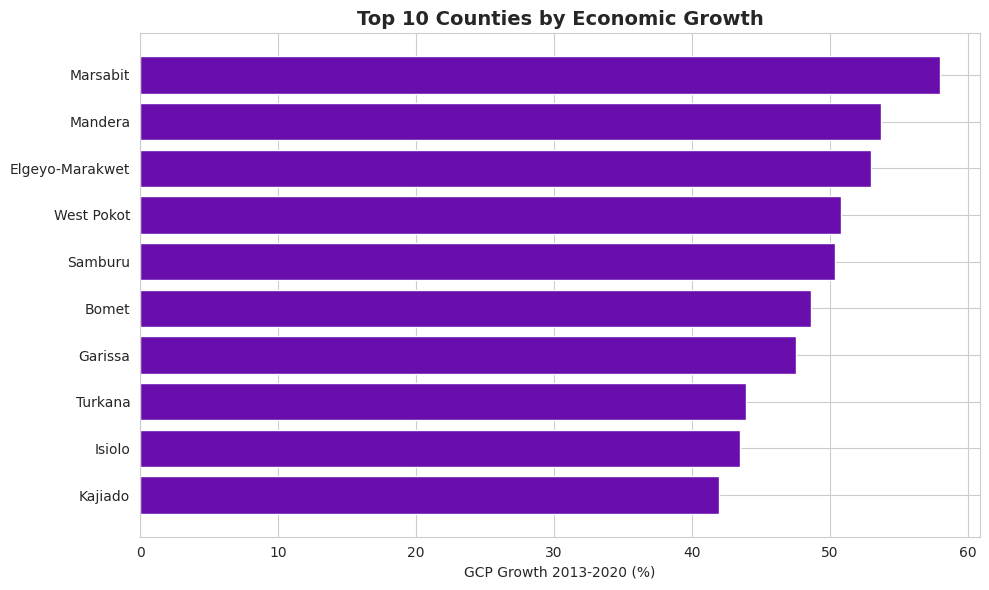

In [12]:
fig, ax = plt.subplots()
top10 = df.nlargest(10, 'GCP_Growth_2013_2020_pct').sort_values('GCP_Growth_2013_2020_pct')
ax.barh(top10['County'], top10['GCP_Growth_2013_2020_pct'], color=PURPLE)
ax.set_xlabel('GCP Growth 2013-2020 (%)')
ax.set_title('Top 10 Counties by Economic Growth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Poverty rate by county (highest 15)

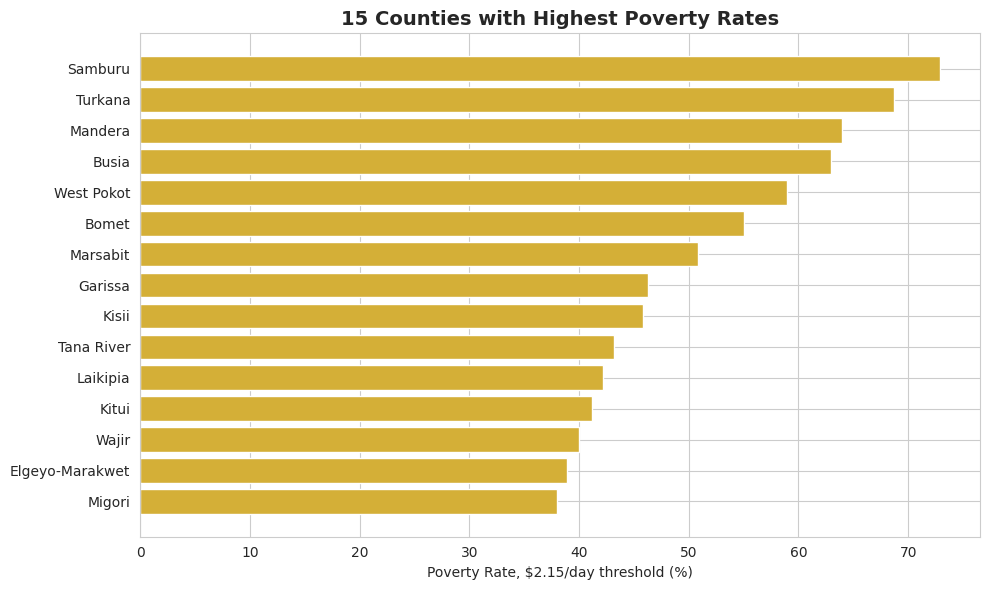

In [13]:
fig, ax = plt.subplots()
top15_poverty = df.nlargest(15, 'Poverty_Rate_2.15usd').sort_values('Poverty_Rate_2.15usd')
ax.barh(top15_poverty['County'], top15_poverty['Poverty_Rate_2.15usd'], color=GOLD)
ax.set_xlabel('Poverty Rate, $2.15/day threshold (%)')
ax.set_title('15 Counties with Highest Poverty Rates', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 GCP growth vs. poverty rate — is there a relationship?

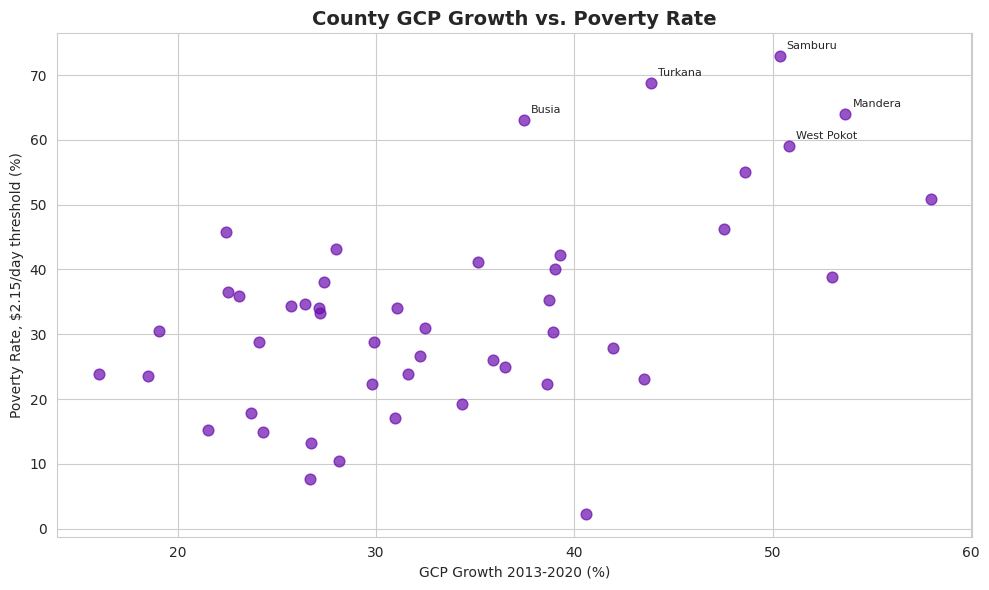

In [14]:
fig, ax = plt.subplots()
ax.scatter(df['GCP_Growth_2013_2020_pct'], df['Poverty_Rate_2.15usd'], color=PURPLE, s=60, alpha=0.7)
ax.set_xlabel('GCP Growth 2013-2020 (%)')
ax.set_ylabel('Poverty Rate, $2.15/day threshold (%)')
ax.set_title('County GCP Growth vs. Poverty Rate', fontsize=14, fontweight='bold')

for _, row in df.iterrows():
    if row['Poverty_Rate_2.15usd'] > 55 or row['GCP_Growth_2013_2020_pct'] > 80:
        ax.annotate(row['County'], (row['GCP_Growth_2013_2020_pct'], row['Poverty_Rate_2.15usd']),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

## 5. Correlation & Simple Regression

Does higher GCP growth actually correlate with lower poverty rates? Let's check the correlation coefficient and fit a simple linear regression.

In [15]:
correlation = df['GCP_Growth_2013_2020_pct'].corr(df['Poverty_Rate_2.15usd'])
print(f"Correlation between GCP growth and poverty rate: {correlation:.3f}")

Correlation between GCP growth and poverty rate: 0.544


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[['GCP_Growth_2013_2020_pct']]
y = df['Poverty_Rate_2.15usd']

model = LinearRegression()
model.fit(X, y)
predictions = model.predict(X)

print(f"Coefficient: {model.coef_[0]:.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"R² score: {r2_score(y, predictions):.3f}")

Coefficient: 0.842
Intercept: 4.838
R² score: 0.296


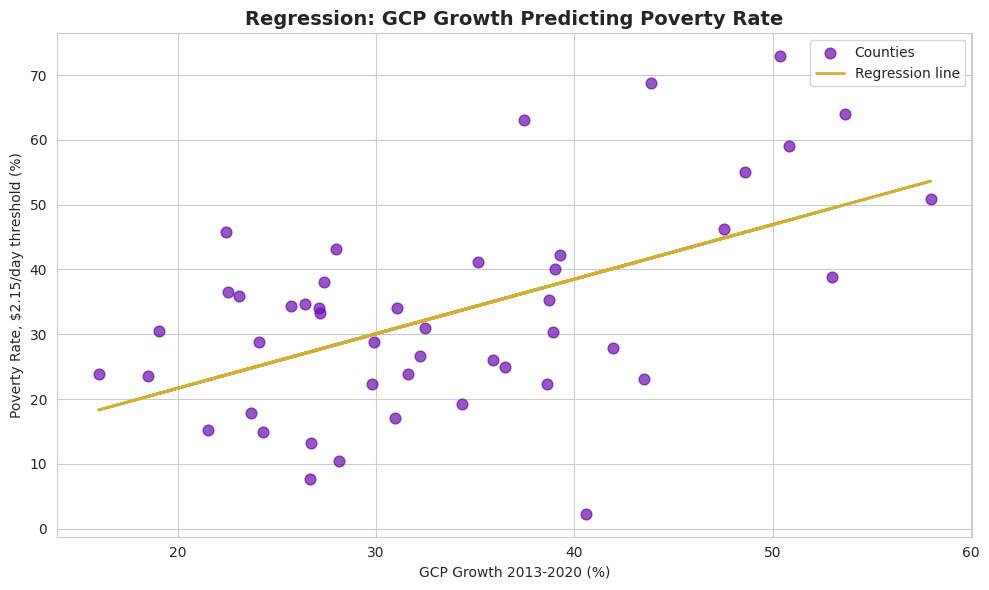

In [17]:
fig, ax = plt.subplots()
ax.scatter(df['GCP_Growth_2013_2020_pct'], df['Poverty_Rate_2.15usd'], color=PURPLE, s=60, alpha=0.7, label='Counties')
ax.plot(df['GCP_Growth_2013_2020_pct'], predictions, color=GOLD, linewidth=2, label='Regression line')
ax.set_xlabel('GCP Growth 2013-2020 (%)')
ax.set_ylabel('Poverty Rate, $2.15/day threshold (%)')
ax.set_title('Regression: GCP Growth Predicting Poverty Rate', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 5.1 Does absolute GCP level matter more than growth rate?

Growth rate measures change, but a county's *current* economic size (GCP level) may be a stronger predictor of poverty than how fast it grew. Let's check.

In [18]:
correlation_level = df['GCP_2020_KShM'].corr(df['Poverty_Rate_2.15usd'])
print(f"Correlation between 2020 GCP level and poverty rate: {correlation_level:.3f}")

Correlation between 2020 GCP level and poverty rate: -0.414


## 6. Key Findings & Conclusion

- The correlation between GCP growth rate (2013-2020) and poverty rate is +0.54 - counties that grew fastest in percentage terms (Marsabit, Mandera, Elgeyo-Marakwet, West Pokot, Samburu) actually tend to have higher, not lower, poverty. This is a classic low base effect: a small economy gaining a modest absolute amount shows up as a large percentage increase, without necessarily lifting poverty.
- The correlation between absolute GCP level (2020) and poverty is -0.41 - counties with genuinely large, established economies (Nairobi, Mombasa) have the lowest poverty rates in the country.
- Together, this suggests that economic scale, not recent growth rate, is the stronger indicator of lower poverty at the county level.

Policy implication: percentage growth figures can be misleading as a standalone development metric for smaller or poorer counties. Absolute economic scale and its distribution likely matter more for poverty reduction than headline growth rates.

**Limitations:**
- Small sample size (47 counties) limits statistical power
- GCP data (2013–2020) and poverty data (2015) are not from the same year
- Poverty rate here uses international thresholds, which may not fully reflect Kenya's national poverty line definitions

---
*Data sources: Kenya National Bureau of Statistics (KNBS) — Gross County Product; World Bank Poverty and Inequality Platform, compiled via Wikipedia.*